<a href="https://colab.research.google.com/github/DiFedorchuk/ML_Course/blob/main/HW_%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

In [3]:
raw_df = pd.read_csv("/content/drive/MyDrive/Courses/Machine Learning/Data/marketing_campaign.csv", sep='\t')

In [4]:
print(f"Кількість рядків: {raw_df.shape[0]}")
print(f"Кількість колонок: {raw_df.shape[1]}")
print("\n Типи даних:")
raw_df.info()
print("\n Пропущені значення:")
print(raw_df.isnull().sum())

Кількість рядків: 2240
Кількість колонок: 29

 Типи даних:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень

In [5]:
median_income = raw_df['Income'].median()
raw_df['Income'] = raw_df['Income'].fillna(median_income)

print(raw_df['Income'].isnull().sum())

0


Вирішив заповнити пропущені значення в колонці Income медіаною, це буде найкращим рішенням для задачі кластеризації, так як дохід у користувачів може кардинально відрізнятись, тому медіана найкраще збереже якість даних

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [11]:
# Feature Engineering
# 'Year_Birth' -> 'Age'
current_year = pd.Timestamp.now().year
raw_df['Age'] = current_year - raw_df['Year_Birth']

# 'Dt_Customer' -> 'Customer_Years'
raw_df['Dt_Customer'] = pd.to_datetime(raw_df['Dt_Customer'], format='%d-%m-%Y')
raw_df['Customer_Years'] = (pd.Timestamp.now() - raw_df['Dt_Customer']).dt.days // 365

# Categorical Features -> One-hot encode 'Education' and 'Marital_Status'
df_new = raw_df.copy()
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_features = encoder.fit_transform(df_new[['Education', 'Marital_Status']])
encoded_feature_names = encoder.get_feature_names_out(['Education', 'Marital_Status'])
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df_new.index)
# Add encoded features to original DataFrame (dropping original columns)
df_processed = pd.concat([
    df_new.drop(columns=['Education', 'Marital_Status']),
    df_encoded
], axis=1)

# 4. Drop irrelevant columns: 'ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'
df_processed = df_processed.drop(columns=['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])

print(df_processed.head())

df_processed.info()

    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  Education_Graduation  \
0              172                88            88  ...                   1.0   
1                2                 1             6  ...                   1.0   
2              111                21            42  ...                   1.0   
3               10                 3             5  ...                   1.0   
4               46                27            15  ...                   0.0   

   Education_Master  Education_P

Можна створити додаткові фічі які допоможуть покращити кластеризацію як Age(кількіть років), Customer_Years(скільки років клієнт з нами), також закодувати One-hot енкодером 'Education' та  'Marital_Status'. Видаляємо їх попередні значення та декілька невалідних колонок як ID, Z_CostContact, Z_Revenue

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [15]:
X = df_processed

In [17]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[2 2 1 ... 2 1 2]


In [18]:
centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the data Dataset Clusters: 0.54


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

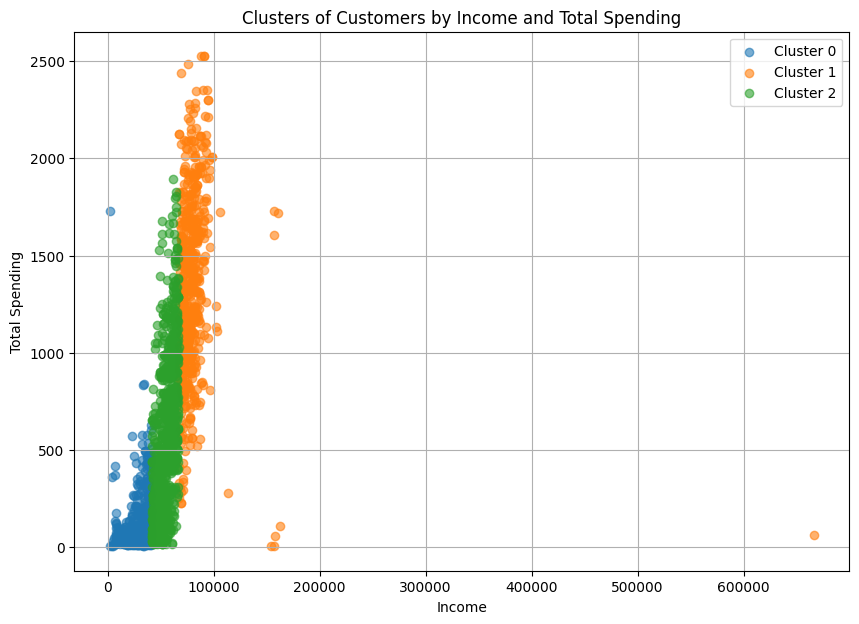

           Income  Total_Spending    Age  NumWebPurchases  NumStorePurchases  \
Cluster                                                                        
0        28991.10           99.79  53.17             2.21               3.11   
1        79448.16         1336.34  58.27             5.37               8.37   
2        54161.95          549.17  60.12             4.89               6.41   

         NumCatalogPurchases  
Cluster                       
0                       0.55  
1                       5.66  
2                       2.46  


In [21]:
df_vizual= df_processed.copy()
df_vizual['Cluster'] = labels
# Combine spending features
df_vizual['Total_Spending'] = df_vizual[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

plt.figure(figsize=(10, 7))
for cluster_id in sorted(df_vizual['Cluster'].unique()):
    cluster_data = df_vizual[df_vizual['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['Income'],
        cluster_data['Total_Spending'],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

plt.title('Clusters of Customers by Income and Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(True)
plt.show()


print(df_vizual.groupby('Cluster')[['Income', 'Total_Spending', 'Age', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']].mean().round(2))


Observation:
Дана візуалізація розділяє клієнтів за сумою доходу та кількостью покупок які вони роблять.

Cluster0 - користувачі які мають низький дохід та роблять мало покупок. Claster1 - користувачі які мають найвищий дохід та роблять багато покупок. Claster2 - користувачі з середнім рівнем доходу та з середніми кількостями покупок

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans_scaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans_scaled.fit(X_scaled)
labels_scaled = kmeans_scaled.predict(X_scaled)
silhouette_scaled = metrics.silhouette_score(X_scaled, labels_scaled, metric='euclidean')
print(f'Silhouette Coefficient for Scaled Data Clusters: {silhouette_scaled:.2f}')

# Compare with unscaled silhouette score
silhouette_unscaled = metrics.silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for Unscaled Data Clusters: {silhouette_unscaled:.2f}')

Silhouette Coefficient for Scaled Data Clusters: 0.14
Silhouette Coefficient for Unscaled Data Clusters: 0.54


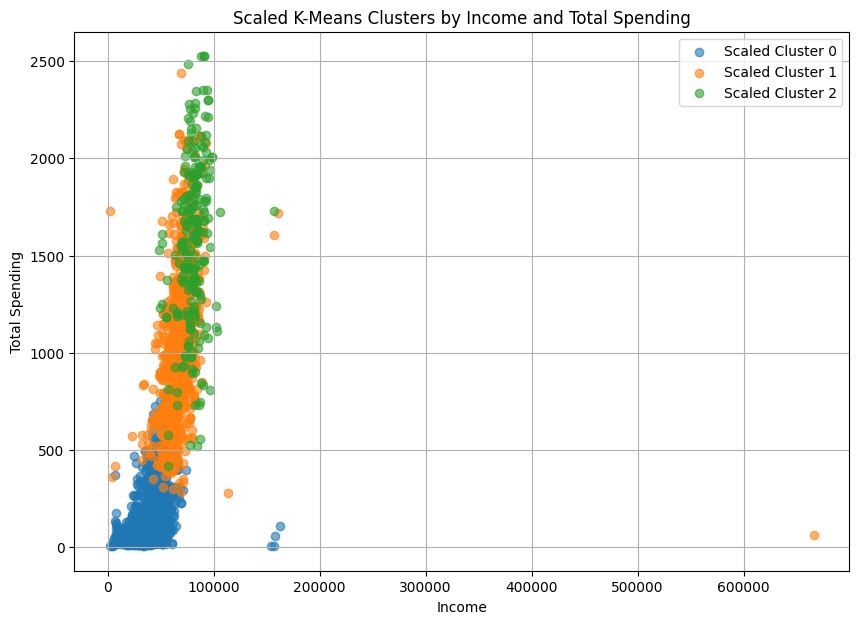

                  Income  Total_Spending    Age  NumWebPurchases  \
Cluster_Scaled                                                     
0               37281.31          146.21  55.44             2.69   
1               67215.76         1037.21  59.85             5.86   
2               80418.89         1568.06  57.51             5.46   

                NumStorePurchases  NumCatalogPurchases  
Cluster_Scaled                                          
0                            3.59                 0.73  
1                            8.50                 4.66  
2                            8.26                 6.11  


In [24]:
df_viz_scaled = df_processed.copy()
df_viz_scaled['Cluster_Scaled'] = labels_scaled
df_viz_scaled['Total_Spending'] = df_viz_scaled[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

plt.figure(figsize=(10, 7))
for cluster_id in sorted(df_viz_scaled['Cluster_Scaled'].unique()):
    cluster_data = df_viz_scaled[df_viz_scaled['Cluster_Scaled'] == cluster_id]
    plt.scatter(
        cluster_data['Income'],
        cluster_data['Total_Spending'],
        label=f'Scaled Cluster {cluster_id}',
        alpha=0.6
    )

plt.title('Scaled K-Means Clusters by Income and Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(True)
plt.show()

print(df_viz_scaled.groupby('Cluster_Scaled')[['Income', 'Total_Spending', 'Age', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']].mean().round(2))

Метрика силуету для масштаюуваних даних 0,14 та нижча за попереднью 0,54, що показує що точки знаходняться близько між кластерами, їх можна віднести до кількох кластерів. Модель без стандартного масштабуавння спрацювала краще

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [25]:
df_no_outliers = df_vizual.copy()
outlier_detection = ['Income', 'Total_Spending']
print(f"Original DataFrame shape: {df_no_outliers.shape}")

for feature in outlier_detection:
    Q1 = df_no_outliers[feature].quantile(0.25)
    Q3 = df_no_outliers[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df_no_outliers[(df_no_outliers[feature] >= lower_bound) & (df_no_outliers[feature] <= upper_bound)]

print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")
print(f"Number of outliers removed: {df_vizual.shape[0] - df_no_outliers.shape[0]}")

Original DataFrame shape: (2240, 37)
DataFrame shape after outlier removal: (2229, 37)
Number of outliers removed: 11
              Income  Total_Spending
count    2229.000000     2229.000000
mean    51579.755047      603.013459
std     20568.154662      597.709432
min      1730.000000        5.000000
25%     35416.000000       69.000000
50%     51381.500000      396.000000
75%     68092.000000     1042.000000
max    113734.000000     2486.000000


**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

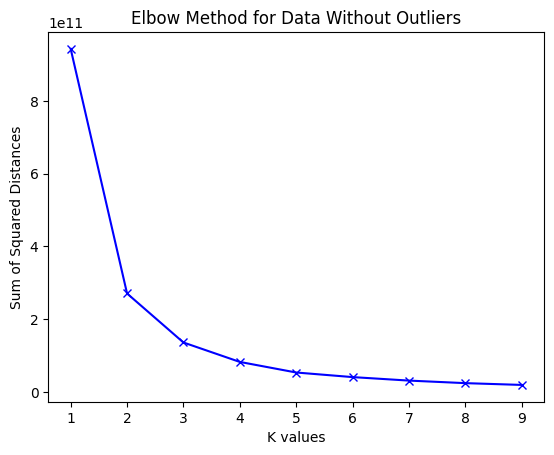

In [27]:
K = range(1,10)
sum_of_squared_distances = []
X_for_elbow = df_no_outliers.drop(columns=['Cluster', 'Total_Spending'])

for k in K:
    model = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_for_elbow)
    sum_of_squared_distances.append(model.inertia_)

plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('K values')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Data Without Outliers')
plt.show()

In [28]:
kmeans = KMeans(n_clusters= 4, n_init='auto', random_state=42)
kmeans.fit(X_for_elbow)
labels = kmeans.predict(X_for_elbow)
print(labels)

centroids = kmeans.cluster_centers_
s = metrics.silhouette_score(X_for_elbow, labels, metric='euclidean')
print(f'Silhouette Coefficient for the data Dataset Clusters: {s:.2f}')

[0 2 1 ... 0 1 0]
Silhouette Coefficient for the data Dataset Clusters: 0.53


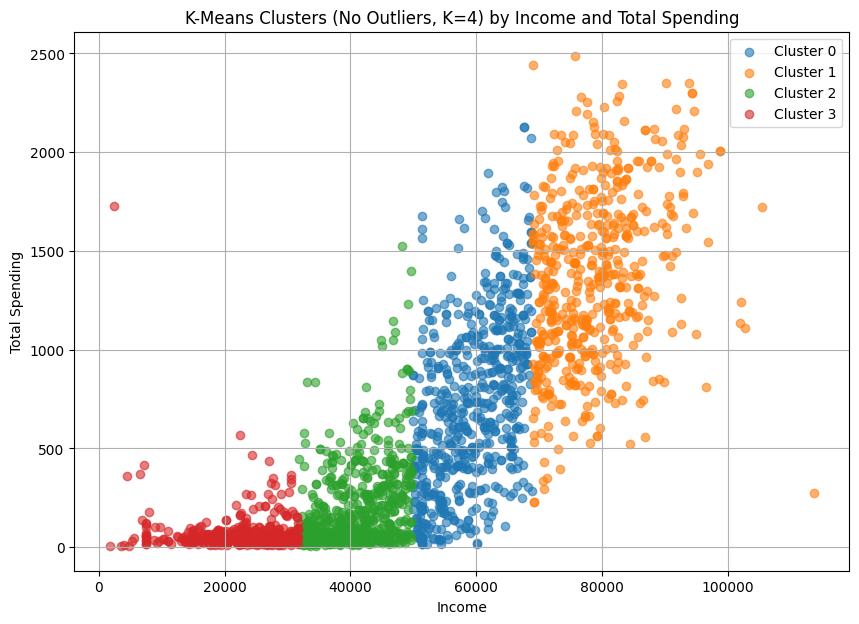

           Income  Total_Spending    Age  NumWebPurchases  NumStorePurchases  \
Cluster                                                                        
0        59192.31          723.45  60.59             5.49               7.41   
1        78636.26         1362.92  58.54             5.38               8.43   
2        40605.59          198.06  56.72             3.07               3.95   
3        22853.43           72.53  51.43             1.94               2.87   

         NumCatalogPurchases  
Cluster                       
0                       3.18  
1                       5.65  
2                       1.00  
3                       0.46  


In [29]:
df_viz_no_outliers = df_no_outliers.copy()
df_viz_no_outliers['Cluster'] = labels

plt.figure(figsize=(10, 7))
for cluster_id in sorted(df_viz_no_outliers['Cluster'].unique()):
    cluster_data = df_viz_no_outliers[df_viz_no_outliers['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['Income'],
        cluster_data['Total_Spending'],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

plt.title('K-Means Clusters (No Outliers, K=4) by Income and Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(True)
plt.show()

print(df_viz_no_outliers.groupby('Cluster')[['Income', 'Total_Spending', 'Age', 'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases']].mean().round(2))

На початку використовував кількість кластерів 3, методі ліктя показав оптимальну кількість кластерів 3 та 4, побудував кластеризацію з кількостю 4, метрика силуету для 3х кластерів 0,54, для 4х кластерів 0,53 покзує що все ж таки 3 кластери більш оптимальна кількість. Візуалізація 4х кластерів показує більш детальний розподіл за доходом та витратами користувачів

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [34]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

dist_sin = linkage(X_for_elbow, method='single')

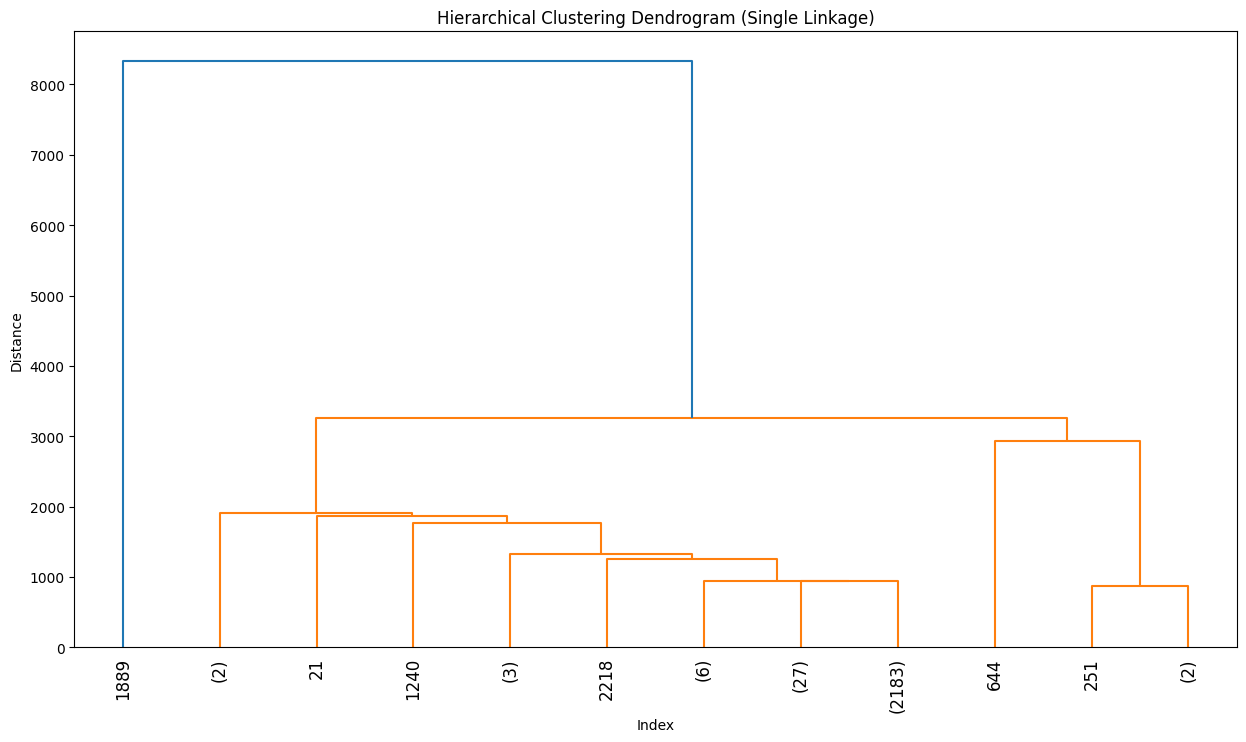

In [37]:
plt.figure(figsize=(15, 8))
dendrogram(dist_sin, truncate_mode='lastp', p=12, show_leaf_counts=True, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Single Linkage)')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()

In [39]:
df_h = df_no_outliers.copy()
df_h['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
df_h['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

<Axes: title={'center': 'K = 3'}, xlabel='Income', ylabel='Total_Spending'>

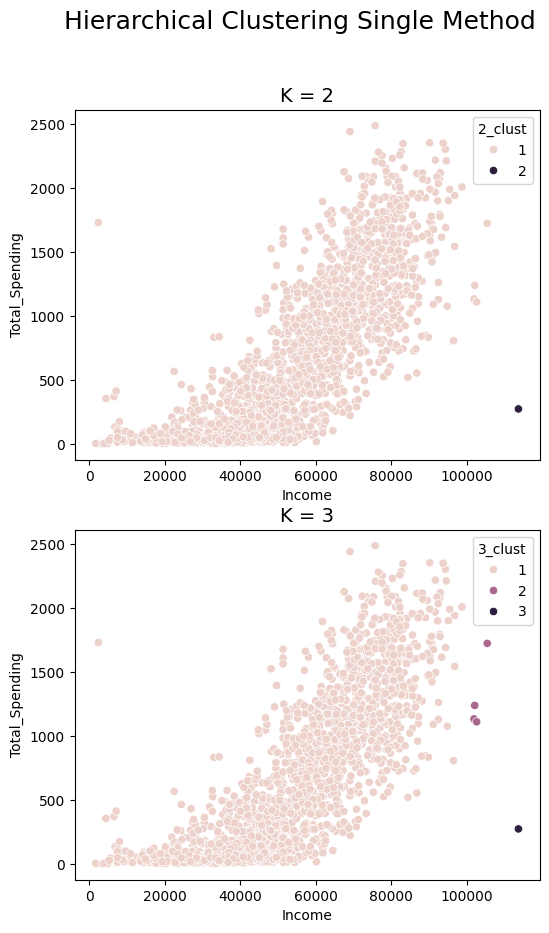

In [43]:
import seaborn as sns

plt.figure(figsize=(6,10))

plt.suptitle("Hierarchical Clustering Single Method",fontsize=18)

plt.subplot(2,1,1)
plt.title("K = 2",fontsize=14)
sns.scatterplot(x="Income",y="Total_Spending", data=df_h, hue="2_clust")

plt.subplot(2,1,2)
plt.title("K = 3",fontsize=14)
sns.scatterplot(x="Income",y="Total_Spending", data=df_h, hue="3_clust")

In [44]:
s_2_clust = metrics.silhouette_score(X_for_elbow, df_h['2_clust'], metric='euclidean')
s_3_clust = metrics.silhouette_score(X_for_elbow, df_h['3_clust'], metric='euclidean')

print(f'Silhouette Coefficient for 2 Hierarchical Clusters: {s_2_clust:.2f}')
print(f'Silhouette Coefficient for 3 Hierarchical Clusters: {s_3_clust:.2f}')

Silhouette Coefficient for 2 Hierarchical Clusters: 0.56
Silhouette Coefficient for 3 Hierarchical Clusters: 0.45


Плоских кластеризація з fcluster на 2 кластери показала найкращу метрику силуету 0,56,  але K-means з метрикою силуету 0,54 візуально більш зрозуміло класифікував дані

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

Silhouette Coefficient for Agglomerative Clustering (n_clusters=3, linkage="ward"): 0.54


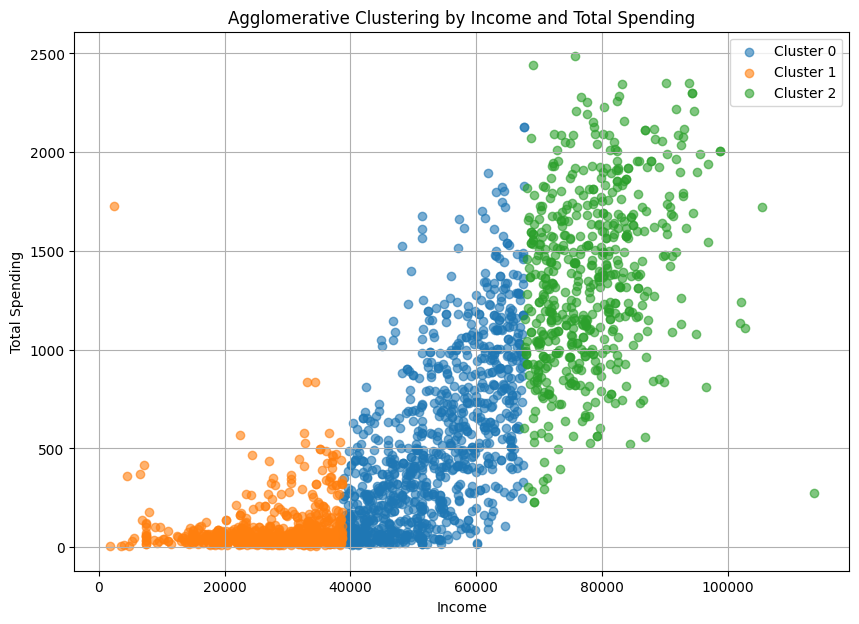

In [46]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_for_elbow)

agg_silhouette = metrics.silhouette_score(X_for_elbow, agg_labels, metric='euclidean')
print(f'Silhouette Coefficient for Agglomerative Clustering (n_clusters=3, linkage="ward"): {agg_silhouette:.2f}')

df_agg_viz = df_no_outliers.copy()
df_agg_viz['Cluster'] = agg_labels

plt.figure(figsize=(10, 7))
for cluster_id in sorted(df_agg_viz['Cluster'].unique()):
    cluster_data = df_agg_viz[df_agg_viz['Cluster'] == cluster_id]
    plt.scatter(
        cluster_data['Income'],
        cluster_data['Total_Spending'],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

plt.title('Agglomerative Clustering by Income and Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(True)
plt.show()

AgglomerativeClustering покав метрику силуету 0,54 що є такою ж як у K-meaans, даний метод також має хороший результат та також добре кластеризує дані